In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase.calculators.espresso import Espresso, EspressoProfile
from ase.eos import EquationOfState
from ase.io import read
from ase.units import GPa, Ry, Angstrom


In [6]:
atoms = read("stis.cif")
orig_cell = atoms.get_cell().copy()
orig_scaled_positions = atoms.get_scaled_positions().copy()
orig_volume = atoms.get_volume()

print(orig_cell)
print(orig_volume)
print(orig_scaled_positions)

Cell([4.1797, 4.1797, 2.6669])
46.590455214821
[[0.      0.      0.     ]
 [0.5     0.5     0.5    ]
 [0.30613 0.30613 0.     ]
 [0.69387 0.69387 0.     ]
 [0.19387 0.80613 0.5    ]
 [0.80613 0.19387 0.5    ]]


In [7]:
pseudo_dir = Path("src").resolve()
pseudopotentials = {"Si": "Si.pbe-n-rrkjus_psl.1.0.0.UPF",
                    "O": "O.pbe-n-kjpaw_psl.0.1.UPF"}

input_data = {
    'control': {
        'calculation': 'vc-relax',       # Options: 'scf', 'relax', 'vc-relax'
        'prefix': 'SiO2',              # Prefix for input/output files
        'verbosity': 'low',
        "pseudo_dir": pseudo_dir,  # Directory for pseudopotentials
        'tprnfor': True,
        'tstress': True,
        'outdir': '.',          # Directory for scratch files
    },
    'system': {
        'ibrav':0,
        # No 'A' here: with ibrav=0, ASE always writes the cell from
        # atoms.get_cell() as an explicit CELL_PARAMETERS card and ignores
        # 'A'/'celldm' for geometry. Worse, QE's namelist parser rejects the
        # lowercase 'a' that ASE's writer emits ("bad line in namelist
        # &system"), so setting it here just crashes pw.x for no benefit.
        # To sweep the lattice parameter, scale atoms.cell instead (see the
        # sweep cells below).
        'nat': 6.0,
        'ntyp': 2.0,
        'ecutwfc': 100.0,            # Wavefunction cutoff in Ry
        'ecutrho': 400.0,          # Charge density cutoff in Ry
        'occupations': 'smearing',
        'smearing': 'mv',
        'degauss': 0.005,
    },
    'electrons': {
        'conv_thr': 1e-08,         # Convergence threshold
        'mixing_beta': 0.7
    },
    'ions': {
        'ion_dynamics': 'bfgs',     # Options: 'bfgs', 'damp', 'cg'
    },
    'cell': {
        'cell_dynamics': 'bfgs',    # Options: 'bfgs', 'damp', 'cg'
        'press': 490,               # Target pressure in kbar
        'press_conv_thr': 0.5,      # Pressure convergence threshold in kbar
    }
}
kpts = (4,4,9)  # k-point mesh

In [8]:
lat_param_add = np.array([-0.12,-0.08,-0.04,0.00,0.04,0.08,0.12])
pressures = [490.00,338.37,218.48,112.45,18.96,-63.15,-135.48]
results_path = Path("volume_sweep_relaxed_results.json")

results = {"volume": [], "energy": []}

a0, b0, c0 = orig_cell.lengths()  # stishovite is tetragonal: a0 == b0
SKIP = [0,2,3,4,5,6]
for i, factor in enumerate(lat_param_add):
    if i in SKIP:
        continue
    
    print(f"{i+1}/{len(lat_param_add)}. A changed by: {factor:+.2f} ang")
    current_config = input_data.copy()
    current_config["cell"]["press"] = pressures[i]

    # Sweep the lattice parameter via atoms.cell, not input_data['system']['A']:
    # with ibrav=0 QE takes the cell from CELL_PARAMETERS regardless of 'A'.
    a_new = a0 + factor
    c_new = a_new * 0.638060147857502
    new_cell = orig_cell.copy()
    new_cell[0] *= a_new / a0
    new_cell[1] *= a_new / b0
    new_cell[2] *= c_new / c0
    atoms.set_cell(new_cell, scale_atoms=True)
    print(f"Target volume: {atoms.get_volume()}")
    

    run_dir = Path(f"A_{factor:.2f}")
    run_dir.mkdir(exist_ok=True)

    profile = EspressoProfile(command='pw.x', pseudo_dir=pseudo_dir)
    atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                        kpts=kpts, input_data=current_config,
                        directory=run_dir)

    try:
        energy_eV = atoms.get_potential_energy()  # runs pw.x and parses the SCF total energy
        energy_Ry = energy_eV / Ry
        volume = atoms.get_volume()
    except Exception as e:
        print(f"Error during calculation: {e}")
        energy_Ry = None
        volume = None
    else:
        (run_dir / "espresso.err").unlink(missing_ok=True)
        (run_dir / "espresso.pwi").unlink(missing_ok=True)

    if energy_Ry is not None:
        print(f"Total energy: {energy_Ry:.6f} Ry")
        print(f"Volume: {volume:.6f} A^3")
    else:
        print("Run failed, no energy recorded.")

    results["volume"].append(volume)
    results["energy"].append(energy_Ry)

    # Persist after every run so progress survives a crash/interrupt.
    results_path.write_text(json.dumps(results, indent=2))

print(f"Saved sweep results to {results_path.resolve()}")
volumes = np.array(results["volume"], dtype=float)
energies_Ry = np.array(results["energy"], dtype=float)

2/7. A changed by: -0.08 ang
Target volume: 43.966090944825325
Total energy: -190.047206 Ry
Volume: 43.966091 A^3
Saved sweep results to /home/yluo/ASE/05b_ev/ase/volume_sweep_relaxed_results.json


In [9]:
load_from_file = True  # set True to plot a previous run instead of the sweep above

if load_from_file:
    results = json.loads(Path("relaxed.json").read_text())
    volumes = np.array(results["volume"], dtype=float)
    energies_Ry = np.array(results["energy"], dtype=float)

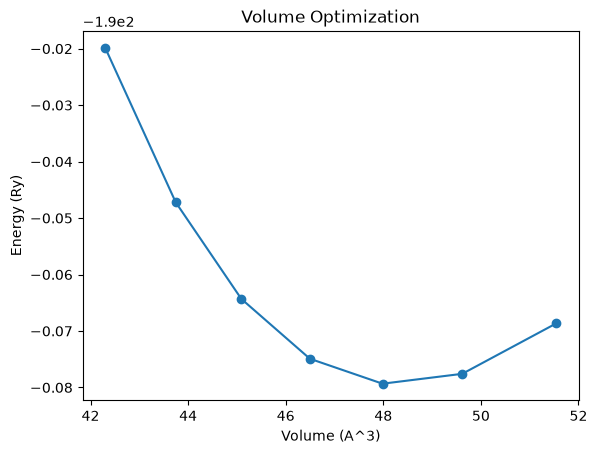

In [10]:

plt.plot(volumes, energies_Ry, 'o-')
plt.xlabel('Volume (A^3)')
plt.ylabel('Energy (Ry)')
plt.title('Volume Optimization')
plt.savefig("ev_curve.png", dpi=150)
plt.show()

V0 = 48.3590 A^3
E0 = -2586.163145 eV
B0 = 258.39 GPa


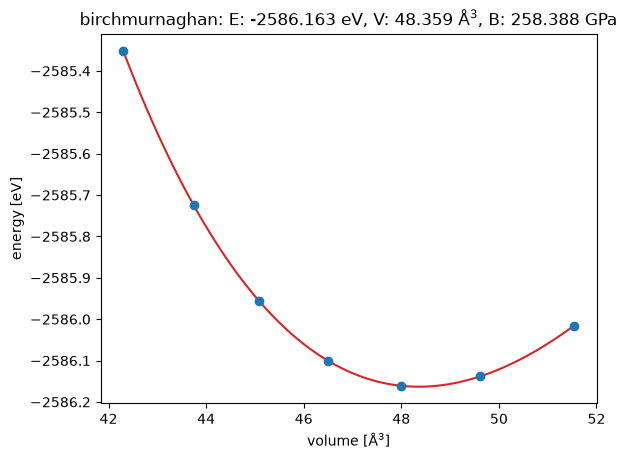

Saved EoS fit results to eos_fit_results.json


In [11]:
# energies_Ry = np.array([-737.528017,-737.542305,-737.541999,-737.530955,-737.511980])
energies_eV = energies_Ry * Ry  # ase.eos expects eV
# volumes = np.array([44.839734,47.642218,50.444701,53.247185,56.049668])

eos = EquationOfState(volumes, energies_eV, eos='birchmurnaghan')
v0, e0, B = eos.fit()

print(f"V0 = {v0:.4f} A^3")
print(f"E0 = {e0:.6f} eV")
print(f"B0 = {B / GPa:.2f} GPa")

eos.plot('eos_fit.png')
plt.show()

eos_summary = {"V0_A3": v0, "E0_eV": e0, "B0_GPa": B / GPa}
Path("eos_fit_results.json").write_text(json.dumps(eos_summary, indent=2))
print("Saved EoS fit results to eos_fit_results.json")